<a href="https://colab.research.google.com/github/ep42south-star/u8254334_EMSC2010-W4-P2/blob/main/EMSC2010_W4_P2_NB1_u8254334.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010_W4_P2_NB1
---

*   Class: EMSC2010
*   Week: 4
*   Session: Practical 2

---

From GitHub, you can open this notebook in Google Colab using the 'Open in Colab' button. Then:

1. Change the notebook name to include your U-number (e.g EMSC2010_W4_P2_NB1_uXXXXXXX.ipynb)
2. Save to Google Drive (*File* >>> *Save a copy in Drive*)

Any edits you make will be saved in your Google Drive. To save your editted version to GitHub

3. Commit to GitHub (*File* >>> *Save a copy in GitHub*)
4. Select the repository for your commit (same as your original repository)
5. Give a brief commit message (e.g. 'Commit including adjustment to labels')
6. Check your GitHub repository, a copy of your notebook should be there.

---

Because Google Drive is saving your work and the work of your collaborators automatically, you don't need to commit all minor edits to GitHub. Rather commit when you want to archive a version of your notebook because you have completed a substantial task.

## Plotting the Keeling curve
Monthly mean carbon dioxide has been measured at Mauna Loa Observatory, Hawaii, since 1958.  The carbon dioxide data on Mauna Loa constitute the longest record of direct measurements of CO$_2$ in the atmosphere.

This record is referred to as the *Keeling curve* in honour of Charles Keeling who started the monitoring program and ran it until his death in 2005.

1. Search for the Mauna Loa monthly CO$_2$ data.
2. Download the data and put it into a Excel workbook (or similar)
3. Create a new Colab notebook (you don't need a GitHub template for this).
4. "Mount" the data in your Colab notebook
5. Use pandas to read in the CO$_2$ data.
6. Use Matplotlib to plot the CO$_2$ data against time, label your axes, etc.
7. Annotate your notebook to describe your workflow, explain your code, cite data sources, etc.
8. This is NOT part of Assessment 1

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
#Data source:
#Keeling, Ralph F.; Morgan, Eric J.; Keeling, Charles D. (2017). Atmospheric Monthly In Situ CO2 Data - Mauna Loa Observatory, Hawaii (Archive 2024-11-13). In Scripps CO2 Program Data. UC San Diego Library Digital Collections. https://doi.org/10.6075/J08W3BHW.
spreadsheet_name = 'Week 4 - Keeling Curve MLO Monthly Data.xlsx'
worksheet_name = 'Data Sheet'

# Load the data without a header, then manually assign headers and skip metadata rows
df_raw = pd.read_excel(spreadsheet_name, sheet_name=worksheet_name, header=None)

# The actual column names are in what pandas initially reads as row 0 (index 0).
# Assign these as new column headers, ensuring to strip any whitespace.
df_raw.columns = df_raw.iloc[0].apply(lambda x: str(x).strip() if pd.notna(x) else x)

# The actual data starts from original Excel row 3 (which is index 2 in df_raw after loading with header=None).
# Keep only data from this row onwards.
df = df_raw.iloc[2:].copy()

# Reset index for a clean DataFrame
df = df.reset_index(drop=True)

# Clean column names by stripping any remaining whitespace (from previous .apply)
df.columns = df.columns.str.strip()

# Rename 'CO2 [ppm]' to 'CO2' for easier access, if it exists
if 'CO2 [ppm]' in df.columns:
    df.rename(columns={'CO2 [ppm]': 'CO2'}, inplace=True)

# Convert relevant columns to numeric, coercing errors will turn non-numeric into NaN
df['CO2'] = pd.to_numeric(df['CO2'], errors='coerce')
df['Date (Decimal)'] = pd.to_numeric(df['Date (Decimal)'], errors='coerce')

# Replace sentinel value -99.99 with NaN (if present, otherwise no effect)
df = df.replace(-99.99, pd.NA)

# Drop rows with NaN values in the essential plotting columns to ensure numeric data
df.dropna(subset=['CO2', 'Date (Decimal)'], inplace=True)

In [48]:
df.head() #retreive data frame

,Yr,Mn,Date,Date (Decimal),CO2,seasonally adjusted [ppm],fit [ppm],seasonally adjusted fit [ppm],CO2 filled [ppm],seasonally adjusted filled [ppm],Sta
1,1958,3,21259,1958.2027,315.71,314.43,316.2,314.91,315.71,314.43,MLO
2,1958,4,21290,1958.2877,317.45,315.15,317.31,314.99,317.45,315.15,MLO
3,1958,5,21320,1958.3699,317.51,314.69,317.89,315.07,317.51,314.69,MLO
5,1958,7,21381,1958.5370,315.87,315.2,315.86,315.22,315.87,315.2,MLO
6,1958,8,21412,1958.6219,314.93,316.22,313.96,315.29,314.93,316.22,MLO


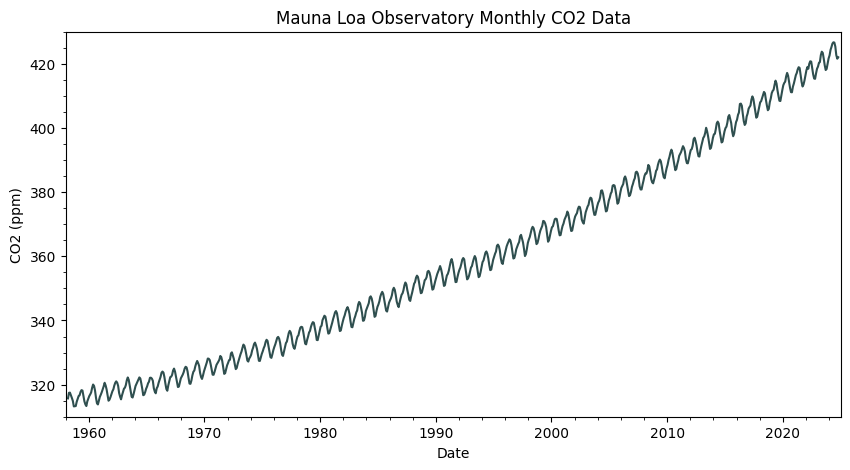

In [51]:
#Create a plot with 10 rows and 5 columns
fig,ax = plt.subplots(figsize=(10,5))

#Plot C02 (in ppm) against date as a decimal
ax.plot(df['Date (Decimal)'], df['CO2'], color='darkslategrey')

#Set the x-axis label as 'Date', set the y-axis label as 'CO2 (ppm)'
ax.set_xlabel('Date')
ax.set_ylabel('CO2 (ppm)')

#Restrict the x-axis to show values from 1958-2025, restrict the y-axis to show values from 310-430
ax.set_xlim([1958,2025])
ax.set_ylim([310,430])

#Set the figure title as 'Mauna Loa Observatory CO2 Data'
ax.set_title('Mauna Loa Observatory Monthly CO2 Data')

#Show minor ticks
ax.minorticks_on()